In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
from tqdm.autonotebook import tqdm
import pandas as pd
import numpy as np
import os
import shlex
import torch

from torch.utils.data import DataLoader
from BasisConvolution.util.hyperparameters import defaultHyperParameters, parseHyperParameters, finalizeHyperParameters
from BasisConvolution.util.arguments import parser
from BasisConvolution.sph.sphOps import sphOperationStates
from BasisConvolution.util.dataloader import datasetLoader, processFolder#, DataLoader
from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.hyperparameters import make_hash, toPandaDict
from BasisConvolution.util.network import buildModel, runInference

from BasisConvolution.util.augment import loadAugmentedBatch
from BasisConvolution.util.hybrid_loss import compute_hybrid_loss, compute_psnr

In [8]:
hyperParameterDict = defaultHyperParameters()
hyperParameterDict['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
# hyperParameterDict['device'] = 'cpu'
hyperParameterDict['augmentAngle'] = False
hyperParameterDict['augmentJitter'] = False
hyperParameterDict['maxRollOut'] = 0

In [9]:
datasetPath = '../../data/SFBC/SFBC_TGV/dataset/train'
basisFunction = 'ffourier'
basisTerms = 4
windowFunction = 'None'

args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1 --hybridLoss --hybridAlpha 0.7 --hybridBeta 0.3'))

hyperParameterDict = parseHyperParameters(args, None)
hyperParameterDict['device'] = 'cuda'
hyperParameterDict['iterations'] = 2**10

train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
print('Dataset has {} samples'.format(len(train_ds)))

print(train_ds.fileFormat)

# print(len(train_ds))
train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
train_iter = iter(train_loader)

finalizeHyperParameters(hyperParameterDict, train_ds)
#hyperParameterDict["targetNeighbors"] = 45.228

config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(123, train_ds, hyperParameterDict, unrollLength=0)


Dataset has 10880 samples
newFormat
Unroll length  1  exceeds maximum, limiting to 0


In [10]:
database = pd.DataFrame()

models = []

t = None
basisFunctions = ['ffourier', 'linear', 'ffourier_even', 'ffourier_odd', 'chebyshev']
for basisFunction in basisFunctions:
    # for basisTerms in [2,4,8]:
    for basisTerms in [4]:
        for windowFunction in ['None']:
            args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth compute[rho]:constant:1/constant:rho0 --boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1 --hybridLoss --hybridAlpha 0.7 --hybridBeta 0.3'))
            #args = parser.parse_args(shlex.split(f'--fluidFeatures constant:1 --groundTruth dt@attribute:rho --boundary False --basisFunctions {basisFunction} --basisTerms {basisTerms} --windowFunction {windowFunction} --maxUnroll 0 --frameDistance 0 --epochs 1'))

            hyperParameterDict = parseHyperParameters(args, None)
            hyperParameterDict['device'] = 'cuda'
            hyperParameterDict['iterations'] = 2**10
            hyperParameterDict['batchSize'] = 8
            # t.


            train_ds = datasetLoader(processFolder(hyperParameterDict, datasetPath))
            # print(len(train_ds))
            train_loader = DataLoader(train_ds, shuffle=True, batch_size = hyperParameterDict['batchSize']).batch_sampler
            train_iter = iter(train_loader)

            finalizeHyperParameters(hyperParameterDict, train_ds)

            if t is None:
                t = tqdm(range(hyperParameterDict['totalIterations']))
            t.reset( hyperParameterDict['totalIterations'])
            # t.n =
            t.set_description(f'{basisFunction} - {basisTerms} - {windowFunction}')

            # print(hyperParameterDict['progressLabel'])

            model, optimizer, scheduler = buildModel(hyperParameterDict, verbose = False)

            model = model.train()

            iterLosses = []
            iterPSNRs = []
            bdatas = []
            iterMSELosses = []          # Track pure MSE component
            iterCorrelationLosses = []   # Track correlation loss component  
            iterRawCorrelations = []     # Track actual correlation values

            # bdata = next(train_iter)
            for i in (range(hyperParameterDict['totalIterations'])):
                try:
                    bdata = next(train_iter)
                except StopIteration:
                    train_iter = iter(train_loader)
                    bdata = next(train_iter)
                bdatas.append(bdata)
                # print(bdata)
                configs, attributes, currentStates, priorStates, trajectoryStates = loadAugmentedBatch(bdata, train_ds, hyperParameterDict, unrollLength=0)
                # config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(bdata[0], train_ds, hyperParameterDict)

                optimizer.zero_grad()
                
                predictions = runInference(currentStates, configs, model, verbose = False)
                # print(predictions)
                if i % 100 == 0 or i < 10:  # Print first 10 iterations and every 100
                    pred_min = predictions[0].min().item()
                    pred_max = predictions[0].max().item()
                    print(f"[{basisFunction}] Iter {i:4d}: Pred[{pred_min:7.3f}, {pred_max:7.3f}]")
                    
                    # Check for explosion
                    if abs(pred_max) > 5.0:
                        print(f"   EXPLOSION in {basisFunction} at iteration {i}!")
                        print(f"   Range: [{pred_min:.1f}, {pred_max:.1f}]")

                gts = [traj[0]['fluid']['target'] for traj in trajectoryStates]

                if hyperParameterDict.get('hybridLoss', False):
                    # Hybrid loss mode
                    loss_dict = compute_hybrid_loss(
                        predictions, gts,
                        alpha=hyperParameterDict['hybridAlpha'],
                        beta=hyperParameterDict['hybridBeta']
                    )
                    
                    loss = loss_dict['total_loss']
                    losses = loss_dict['individual_mse']  # For compatibility with existing code
                    psnrs = compute_psnr(predictions, gts)
                    psnr = torch.stack(psnrs).mean()
                    
                    # Track additional metrics
                    iterMSELosses.append(loss_dict['mse_loss'].item())
                    iterCorrelationLosses.append(loss_dict['correlation_loss'].item())
                    iterRawCorrelations.append(loss_dict['raw_correlation'].item())
                    
                else:
                    # Standard MSE loss (existing behavior)
                    losses = [torch.nn.functional.mse_loss(prediction, gt) for prediction, gt in zip(predictions, gts)]
                    psnrs = [20 * torch.log10(gt.abs().max()) - 10 * torch.log10(loss) for gt, loss in zip(gts, losses)]
                    loss = torch.stack(losses).mean()
                    psnr = torch.stack(psnrs).mean()

                loss.backward()


                iterLosses.append([l.item() for l in losses])
                iterPSNRs.append([p.item() for p in psnrs])
                optimizer.step()
                if hyperParameterDict.get('hybridLoss', False):
                    t.set_description(f'{bdata} - {hyperParameterDict["progressLabel"]} - Loss: {loss.item():.4e}, MSE: {loss_dict["mse_loss"].item():.4e}, Corr: {loss_dict["raw_correlation"].item():.3f}, PSNR: {psnr.item():.2f}')
                else:
                    t.set_description(f'{bdata} - {hyperParameterDict["progressLabel"]} - Loss: {loss.item():.4e}, PSNR: {psnr.item():.2f}')
                t.update()
                t.refresh()
            dataFrame = pd.DataFrame([toPandaDict(hyperParameterDict)] * len(bdatas))

            dataFrame['batches'] = bdatas
            for b in range(len(bdata)):
                dataFrame['losses_{}'.format(b)] = [iterLosses[i][b] for i in range(len(bdatas))]
                dataFrame['psnrs_{}'.format(b)] = [iterPSNRs[i][b] for i in range(len(bdatas))]

            dataFrame['losses'] = [np.mean(iterLosses[i]) for i in range(len(bdatas))]
            dataFrame['psnrs'] = [np.mean(iterPSNRs[i]) for i in range(len(bdatas))]
            dataFrame['iteration'] = np.arange(len(bdatas))

            # Save hybrid loss metrics if hybrid loss is enabled
            if hyperParameterDict.get('hybridLoss', False):
                dataFrame['mse_component'] = iterMSELosses
                dataFrame['correlation_component'] = iterCorrelationLosses  
                dataFrame['raw_correlation'] = iterRawCorrelations

            database = pd.concat([database, dataFrame], ignore_index = True)
            models.append(model)


Unroll length  1  exceeds maximum, limiting to 0


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


  0%|          | 0/1024 [00:00<?, ?it/s]

[ffourier] Iter    0: Pred[  0.136,   0.350]
[ffourier] Iter    1: Pred[  0.311,   0.499]
[ffourier] Iter    2: Pred[  0.429,   0.632]
[ffourier] Iter    3: Pred[  0.583,   0.783]
[ffourier] Iter    4: Pred[  0.690,   0.937]
[ffourier] Iter    5: Pred[  0.809,   1.065]
[ffourier] Iter    6: Pred[  0.905,   1.195]
[ffourier] Iter    7: Pred[  0.989,   1.293]
[ffourier] Iter    8: Pred[  1.070,   1.362]
[ffourier] Iter    9: Pred[  1.108,   1.429]
[ffourier] Iter  100: Pred[  1.020,   1.048]
[ffourier] Iter  200: Pred[  1.011,   1.034]
[ffourier] Iter  300: Pred[  0.998,   1.017]
[ffourier] Iter  400: Pred[  1.003,   1.020]
[ffourier] Iter  500: Pred[  1.003,   1.022]
[ffourier] Iter  600: Pred[  1.005,   1.026]
[ffourier] Iter  700: Pred[  1.005,   1.025]
[ffourier] Iter  800: Pred[  1.005,   1.023]
[ffourier] Iter  900: Pred[  1.003,   1.020]
[ffourier] Iter 1000: Pred[  1.001,   1.020]
Unroll length  1  exceeds maximum, limiting to 0


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


...

[ffourier_even] Iter    0: Pred[  0.205,   0.470]
[ffourier_even] Iter    1: Pred[  0.388,   0.642]
[ffourier_even] Iter    2: Pred[  0.566,   0.789]
[ffourier_even] Iter    3: Pred[  0.679,   0.962]
[ffourier_even] Iter    4: Pred[  0.837,   1.090]
[ffourier_even] Iter    5: Pred[  0.951,   1.226]
[ffourier_even] Iter    6: Pred[  1.044,   1.314]
[ffourier_even] Iter    7: Pred[  1.088,   1.383]
[ffourier_even] Iter    8: Pred[  1.115,   1.427]
[ffourier_even] Iter    9: Pred[  1.114,   1.423]
[ffourier_even] Iter  100: Pred[  0.971,   1.020]
[ffourier_even] Iter  200: Pred[  1.015,   1.049]
[ffourier_even] Iter  300: Pred[  1.008,   1.032]
[ffourier_even] Iter  400: Pred[  1.020,   1.043]
[ffourier_even] Iter  500: Pred[  1.021,   1.046]
[ffourier_even] Iter  600: Pred[  1.010,   1.032]
[ffourier_even] Iter  700: Pred[  1.009,   1.036]
[ffourier_even] Iter  800: Pred[  1.014,   1.033]
[ffourier_even] Iter  900: Pred[  1.007,   1.028]
[ffourier_even] Iter 1000: Pred[  1.001,   1.024]


/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


[ffourier_odd] Iter    0: Pred[  0.151,   0.390]
[ffourier_odd] Iter    1: Pred[  0.261,   0.425]
[ffourier_odd] Iter    2: Pred[  0.354,   0.473]
[ffourier_odd] Iter    3: Pred[  0.421,   0.569]
[ffourier_odd] Iter    4: Pred[  0.484,   0.653]
[ffourier_odd] Iter    5: Pred[  0.548,   0.706]
[ffourier_odd] Iter    6: Pred[  0.601,   0.785]
[ffourier_odd] Iter    7: Pred[  0.651,   0.863]
[ffourier_odd] Iter    8: Pred[  0.732,   0.931]
[ffourier_odd] Iter    9: Pred[  0.768,   0.980]
[ffourier_odd] Iter  100: Pred[  0.862,   1.116]
[ffourier_odd] Iter  200: Pred[  0.887,   1.116]
[ffourier_odd] Iter  300: Pred[  0.875,   1.121]
[ffourier_odd] Iter  400: Pred[  0.864,   1.098]
[ffourier_odd] Iter  500: Pred[  0.887,   1.116]
[ffourier_odd] Iter  600: Pred[  0.870,   1.114]
[ffourier_odd] Iter  700: Pred[  0.884,   1.117]
[ffourier_odd] Iter  800: Pred[  0.884,   1.126]
[ffourier_odd] Iter  900: Pred[  0.888,   1.119]
[ffourier_odd] Iter 1000: Pred[  0.865,   1.119]
Unroll length  1  ex

/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/SFBC/src/BasisConvolution/util/hyperparameters.py:750: UserWarning: Boundary data requested but not available. Disabling boundary data.
  warnings.warn('Boundary data requested but not available. Disabling boundary data.')


[chebyshev] Iter    0: Pred[  1.404,   1.819]
[chebyshev] Iter    1: Pred[  0.456,   0.860]
[chebyshev] Iter    2: Pred[  0.265,   0.635]
[chebyshev] Iter    3: Pred[  0.546,   0.878]
[chebyshev] Iter    4: Pred[  0.907,   1.277]
[chebyshev] Iter    5: Pred[  1.184,   1.579]
[chebyshev] Iter    6: Pred[  1.210,   1.626]
[chebyshev] Iter    7: Pred[  1.060,   1.474]
[chebyshev] Iter    8: Pred[  0.856,   1.241]
[chebyshev] Iter    9: Pred[  0.644,   0.988]
[chebyshev] Iter  100: Pred[  0.945,   1.064]
[chebyshev] Iter  200: Pred[  0.968,   1.072]
[chebyshev] Iter  300: Pred[  1.061,   1.110]
[chebyshev] Iter  400: Pred[  0.909,   0.978]
[chebyshev] Iter  500: Pred[  0.917,   1.006]
[chebyshev] Iter  600: Pred[  0.973,   1.024]
[chebyshev] Iter  700: Pred[  0.989,   1.030]
[chebyshev] Iter  800: Pred[  0.967,   1.010]
[chebyshev] Iter  900: Pred[  1.064,   1.108]
[chebyshev] Iter 1000: Pred[  0.859,   1.175]


In [11]:
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
import numpy as np

from BasisConvolution.util.augment import loadAugmentedFrame
from BasisConvolution.util.network import runInference

In [12]:
basisTerms = database['basisTerms'].unique()
basisFunctions = database['basisFunctions'].unique()

print(basisTerms)
print(basisFunctions)

hues = sns.color_palette(n_colors = len(basisFunctions))
linestyles = ['--', '-', ':', '-.']

[4]
['ffourier' 'linear' 'ffourier_even' 'ffourier_odd' 'chebyshev']


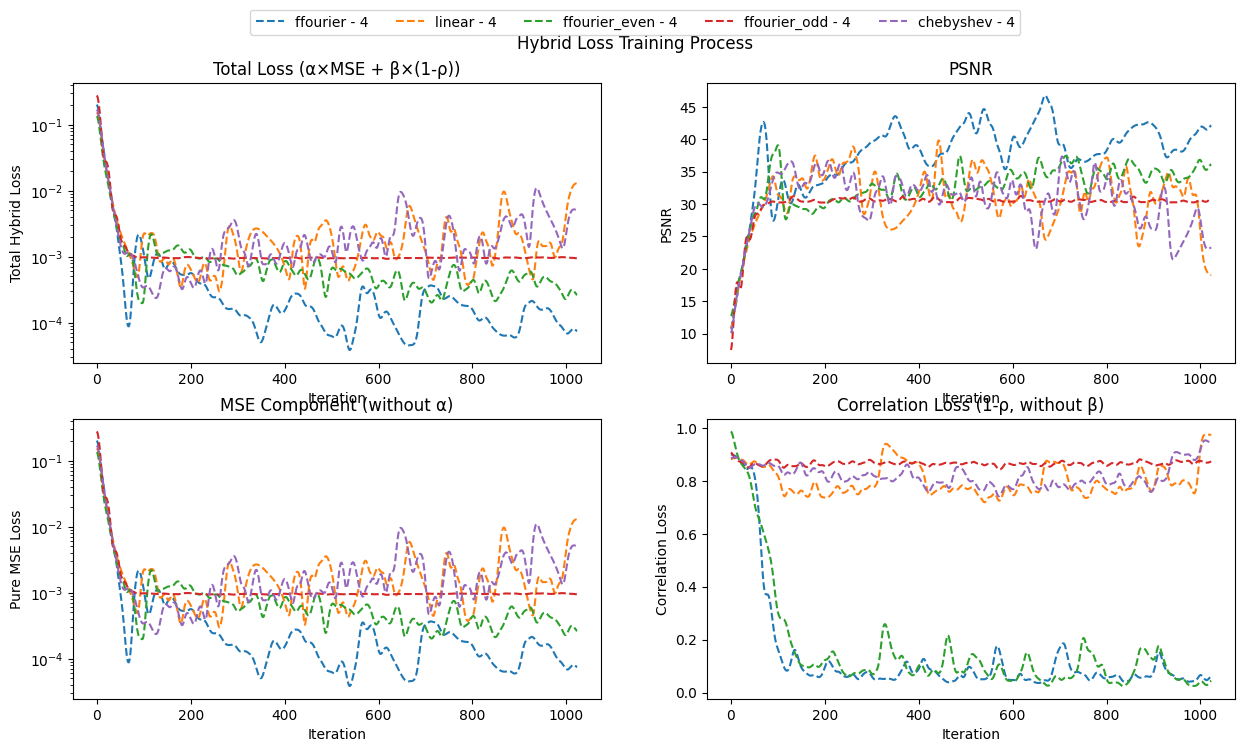

In [13]:
# Check if any model used hybrid loss
hybrid_used = any('mse_component' in database.columns and 
                 database['mse_component'].notna().any() for database in [database])

if hybrid_used:
    # Plot 4 subplots for hybrid loss mode
    fig, axis = plt.subplots(2, 2, figsize=(15, 8), sharey=False, squeeze=False)
    
    for i, basisFunction in enumerate(basisFunctions):
        for j, basisTerm in enumerate(basisTerms):
            subDatabase = database[(database['basisFunctions'] == basisFunction) & (database['basisTerms'] == basisTerm)]
            
            iters = subDatabase['iteration']
            losses = subDatabase['losses']  # Total hybrid loss
            psnrs = subDatabase['psnrs']
            mse_components = subDatabase['mse_component']  # Pure MSE without coefficient
            correlation_components = subDatabase['correlation_component']  # Pure correlation loss without coefficient
            
            # Apply smoothing
            losses = gaussian_filter1d(losses, sigma=5)
            psnrs = gaussian_filter1d(psnrs, sigma=5)
            mse_components = gaussian_filter1d(mse_components, sigma=5)
            correlation_components = gaussian_filter1d(correlation_components, sigma=5)
            
            # Plot total hybrid loss
            axis[0,0].plot(iters, losses, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            
            # Plot PSNR
            axis[0,1].plot(iters, psnrs, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            
            # Plot pure MSE component (without alpha coefficient)
            axis[1,0].plot(iters, mse_components, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            
            # Plot pure correlation loss component (without beta coefficient) 
            axis[1,1].plot(iters, correlation_components, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
    
    # Configure subplots
    axis[0,0].set_yscale('log')
    axis[0,0].set_xlabel('Iteration')
    axis[0,0].set_ylabel('Total Hybrid Loss')
    axis[0,0].set_title('Total Loss (α×MSE + β×(1-ρ))')
    
    axis[0,1].set_xlabel('Iteration')
    axis[0,1].set_ylabel('PSNR')
    axis[0,1].set_title('PSNR')
    
    axis[1,0].set_yscale('log')
    axis[1,0].set_xlabel('Iteration')
    axis[1,0].set_ylabel('Pure MSE Loss')
    axis[1,0].set_title('MSE Component (without α)')
    
    axis[1,1].set_xlabel('Iteration')
    axis[1,1].set_ylabel('Correlation Loss')
    axis[1,1].set_title('Correlation Loss (1-ρ, without β)')
    
    # Add legend
    handles, labels = axis[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.98))
    
    fig.suptitle('Hybrid Loss Training Process', y=0.94)
    fig.subplots_adjust(top=0.88)
    
else:
    # Standard plotting (your current implementation)
    fig, axis = plt.subplots(1, 2, figsize=(10, 4), sharey=False, squeeze=False)
    
    for i, basisFunction in enumerate(basisFunctions):
        for j, basisTerm in enumerate(basisTerms):
            subDatabase = database[(database['basisFunctions'] == basisFunction) & (database['basisTerms'] == basisTerm)]
            
            iters = subDatabase['iteration']
            losses = subDatabase['losses']
            psnrs = subDatabase['psnrs']
            
            losses = gaussian_filter1d(losses, sigma=5)
            psnrs = gaussian_filter1d(psnrs, sigma=5)
            
            axis[0,0].plot(iters, losses, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
            axis[0,1].plot(iters, psnrs, label=f'{basisFunction} - {basisTerm}', color=hues[i], ls=linestyles[j])
    
    axis[0,0].set_yscale('log')
    axis[0,0].set_xlabel('Iteration')
    axis[0,0].set_ylabel('Loss')
    
    axis[0,1].set_xlabel('Iteration')
    axis[0,1].set_ylabel('PSNR')
    
    handles, labels = axis[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 0.95))
    
    fig.suptitle('Training process')
    fig.subplots_adjust(top=0.725)

plt.show()


In [14]:
# Save all models
if len(models) > 0:
    # If you have a list of basis function names corresponding to models, use it; otherwise, generate generic names
    if 'basisFunctions' in locals() and len(basisFunctions) == len(models):
        model_names = list(basisFunctions)
    else:
        model_names = [f"model_{i}" for i in range(len(models))]
    models_dict = {name: model for name, model in zip(model_names, models)}

from model_utils import save_model, save_hyperparameters

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default"

# Save hyperparameters once
save_hyperparameters(hyperParameterDict, save_dir)

# Save all models individually  
for basis_name, model in models_dict.items():
    save_model(model, basis_name, save_dir)

✅ Saved hyperparameters to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/hyperparameters.pth
✅ Saved ffourier model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/ffourier_model.pth
✅ Saved linear model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/linear_model.pth
✅ Saved ffourier_even model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/ffourier_even_model.pth
✅ Saved ffourier_odd model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/ffourier_odd_model.pth
✅ Saved chebyshev model to /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/chebyshev_model.pth


In [15]:
from model_utils import load_models_for_visualization

save_dir = "/home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default"

models_dict, hyperParameterDict = load_models_for_visualization(save_dir)

Found saved models: ['ffourier', 'ffourier_even', 'ffourier_odd', 'linear', 'chebyshev']
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/hyperparameters.pth
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/hyperparameters.pth
✅ Created BasisNetwork for newer model: ffourier
✅ Loaded ffourier model from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/ffourier_model.pth
✅ Loaded hyperparameters from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/hyperparameters.pth
✅ Created BasisNetwork for newer model: ffourier_even
✅ Loaded ffourier_even model from /home/yusuf/Physics_Emulators_using_Continuous_Convolutions/models/SFBC_TGV/density_correlation/default/ffourier_even_model.pth
✅ Loaded hyperparameters from /h

In [16]:
test_datasetPath = '../../data/SFBC/SFBC_TGV/dataset/test'
test_ds = datasetLoader(processFolder(hyperParameterDict, test_datasetPath))
finalizeHyperParameters(hyperParameterDict, test_ds)

sample_idx = 0
config, attributes, currentState, priorState, trajectoryStates = loadAugmentedFrame(sample_idx, test_ds, hyperParameterDict)

if 'fluid' in currentState:
    fluid_positions = currentState['fluid']['positions']
    num_particles = fluid_positions.shape[0]
    spatial_dims = fluid_positions.shape[1]
    print(f'Number of particles per trajectory: {num_particles:,}')
    print(f'Spatial dimensions: {spatial_dims}D')

import os
import h5py

test_files = [f for f in os.listdir(test_datasetPath) if f.endswith('.hdf5')]
sample_file = os.path.join(test_datasetPath, test_files[0])

with h5py.File(sample_file, 'r') as f:
    if 'simulationExport' in f:
        timestep_groups = [key for key in f['simulationExport'].keys() if key.isdigit()]
        frames_per_trajectory = len(timestep_groups)

total_trajectories = len(test_files)
total_frames_combined = len(test_ds)

print(f'Test trajectories: {total_trajectories}')
print(f'Frames per trajectory: {frames_per_trajectory}')
print(f'Total frames in combined dataset: {total_frames_combined:,}')

import random
random_trajectory_idx = random.randint(0, total_trajectories - 1)
print(f'Selected test trajectory #{random_trajectory_idx}')

finalizeHyperParameters(hyperParameterDict, test_ds)

Unroll length  1  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Number of particles per trajectory: 16,384
Spatial dimensions: 2D
Test trajectories: 43
Frames per trajectory: 128
Total frames in combined dataset: 5,504
Selected test trajectory #40
Unroll length  1  exceeds maximum, limiting to 0


{'coordinateMapping': 'cartesian',
 'windowFunction': 'None',
 'liLoss': 'yes',
 'initialLR': 0.01,
 'finalLR': 0.0001,
 'lrStep': 10,
 'epochs': 1,
 'frameDistance': 0,
 'iterations': 1024,
 'dataDistance': 1,
 'cutoff': 1800,
 'dataLimit': -1,
 'seed': 42,
 'minUnroll': 2,
 'maxUnroll': 0,
 'historyLength': 0,
 'augmentAngle': False,
 'augmentJitter': False,
 'jitterAmount': 0.1,
 'networkSeed': 42,
 'network': 'default',
 'normalized': False,
 'adjustForFrameDistance': True,
 'weight_decay': 0,
 'input': './',
 'output': 'training',
 'loss': 'mse',
 'batchSize': 8,
 'hybridLoss': True,
 'hybridAlpha': 0.7,
 'hybridBeta': 0.3,
 'fluidFeatures': 'constant:1',
 'boundaryFeatures': 'False',
 'boundary': False,
 'groundTruth': 'compute[rho]:constant:1/constant:rho0',
 'gtMode': 'abs',
 'verbose': False,
 'independent_dxdt': False,
 'unrollIncrement': 100,
 'networkType': 'w/o shift',
 'normalization': 'none',
 'skipLastShift': False,
 'shiftLoss': False,
 'activation': 'silu',
 'dataInde

In [17]:
frames_to_plot = [1, 30, 50, 100, 127]
figsize = (12, 12)
frame_idx = 16
 
print(f"Available models: {list(models_dict.keys())}")
print(f"Plotting frames: {frames_to_plot}")

Available models: ['ffourier', 'ffourier_even', 'ffourier_odd', 'linear', 'chebyshev']
Plotting frames: [1, 30, 50, 100, 127]


In [18]:
from plotting_utils import *

Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


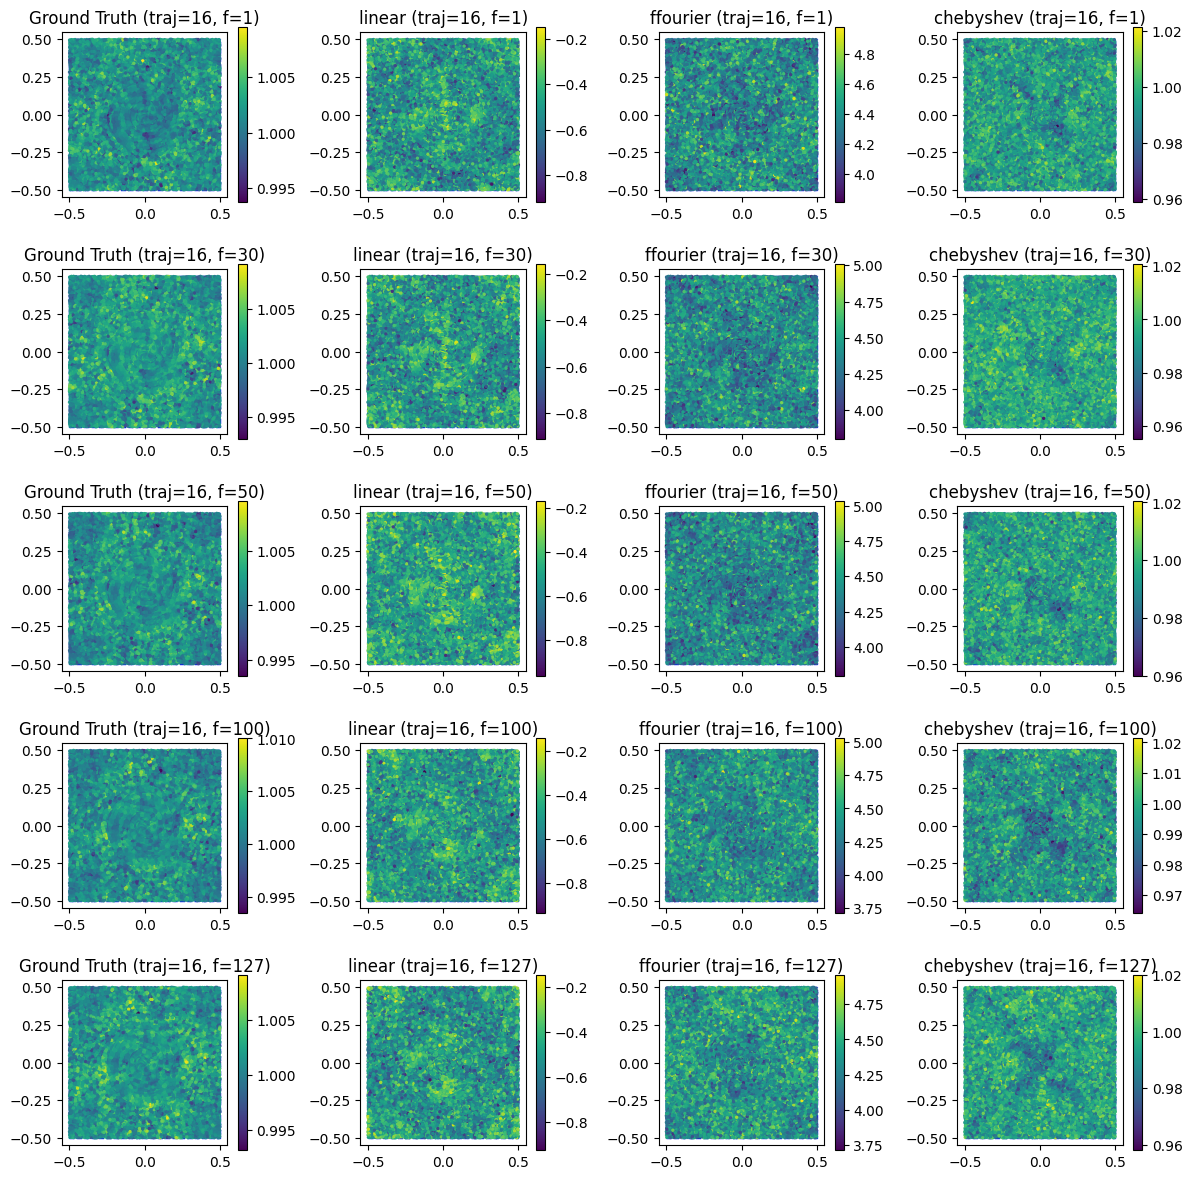

In [9]:
visualize_density_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize,
    frames_per_trajectory=128
)

Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0
Unroll length  8  exceeds maximum, limiting to 0


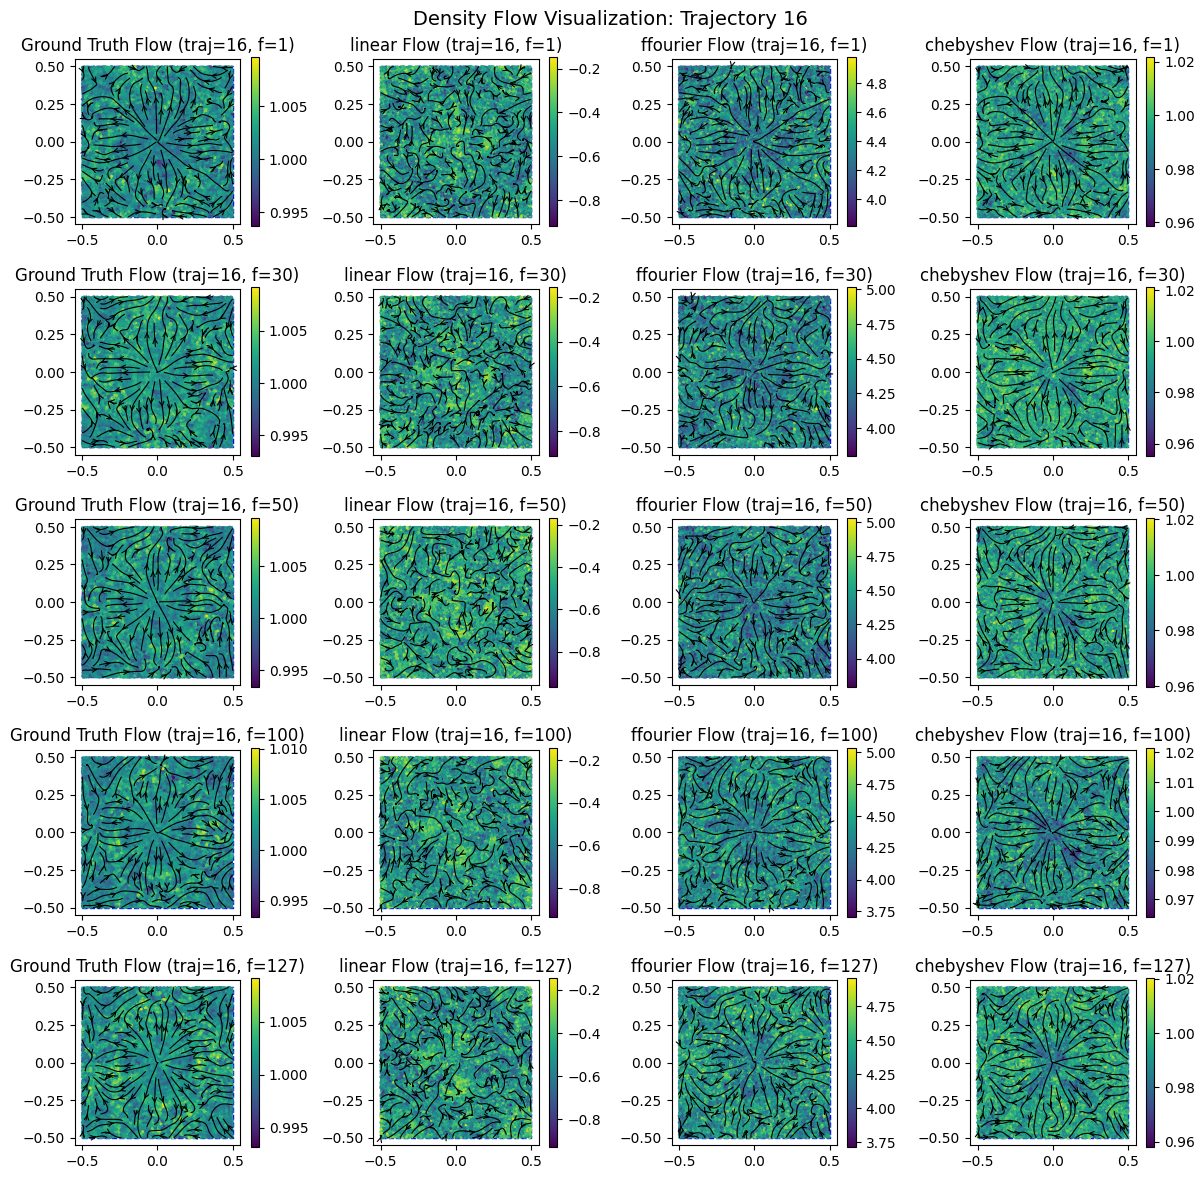

In [40]:
visualize_flow_comparison_sph(models_dict=models_dict,
    ds=test_ds,
    hyperParameterDict=hyperParameterDict,
    frames=frames_to_plot,
    trajectory_index=frame_idx,
    figsize=figsize,
    frames_per_trajectory=128
)